# DECISION TREE ALGORITHM------------

In [ ]:
# Regression ----

In [97]:
import pandas as pd

from sklearn.tree import DecisionTreeRegressor  #Regressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn import tree

import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
df= pd.read_csv(r'D:\datasets\salary_data (1).csv')  # Data Loading--
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [99]:
df.shape

(30, 2)

In [100]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [101]:
df.duplicated().sum()

np.int64(0)

In [102]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [103]:
df.shape

(30, 2)

In [104]:
x= df[["YearsExperience"]]
y =df ["Salary"]
x,y

(    YearsExperience
 0               1.1
 1               1.3
 2               1.5
 3               2.0
 4               2.2
 5               2.9
 6               3.0
 7               3.2
 8               3.2
 9               3.7
 10              3.9
 11              4.0
 12              4.0
 13              4.1
 14              4.5
 15              4.9
 16              5.1
 17              5.3
 18              5.9
 19              6.0
 20              6.8
 21              7.1
 22              7.9
 23              8.2
 24              8.7
 25              9.0
 26              9.5
 27              9.6
 28             10.3
 29             10.5,
 0      39343.0
 1      46205.0
 2      37731.0
 3      43525.0
 4      39891.0
 5      56642.0
 6      60150.0
 7      54445.0
 8      64445.0
 9      57189.0
 10     63218.0
 11     55794.0
 12     56957.0
 13     57081.0
 14     61111.0
 15     67938.0
 16     66029.0
 17     83088.0
 18     81363.0
 19     93940.0
 20     91738.0
 21     9827

In [105]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [107]:
dt = DecisionTreeRegressor()
dt.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [54]:
y_pred = dt.predict(x_test)

In [55]:
dt.score(x_test,y_test)

0.8021759743735162

In [56]:
dt.score(x_train,y_train)

0.9999631319936537

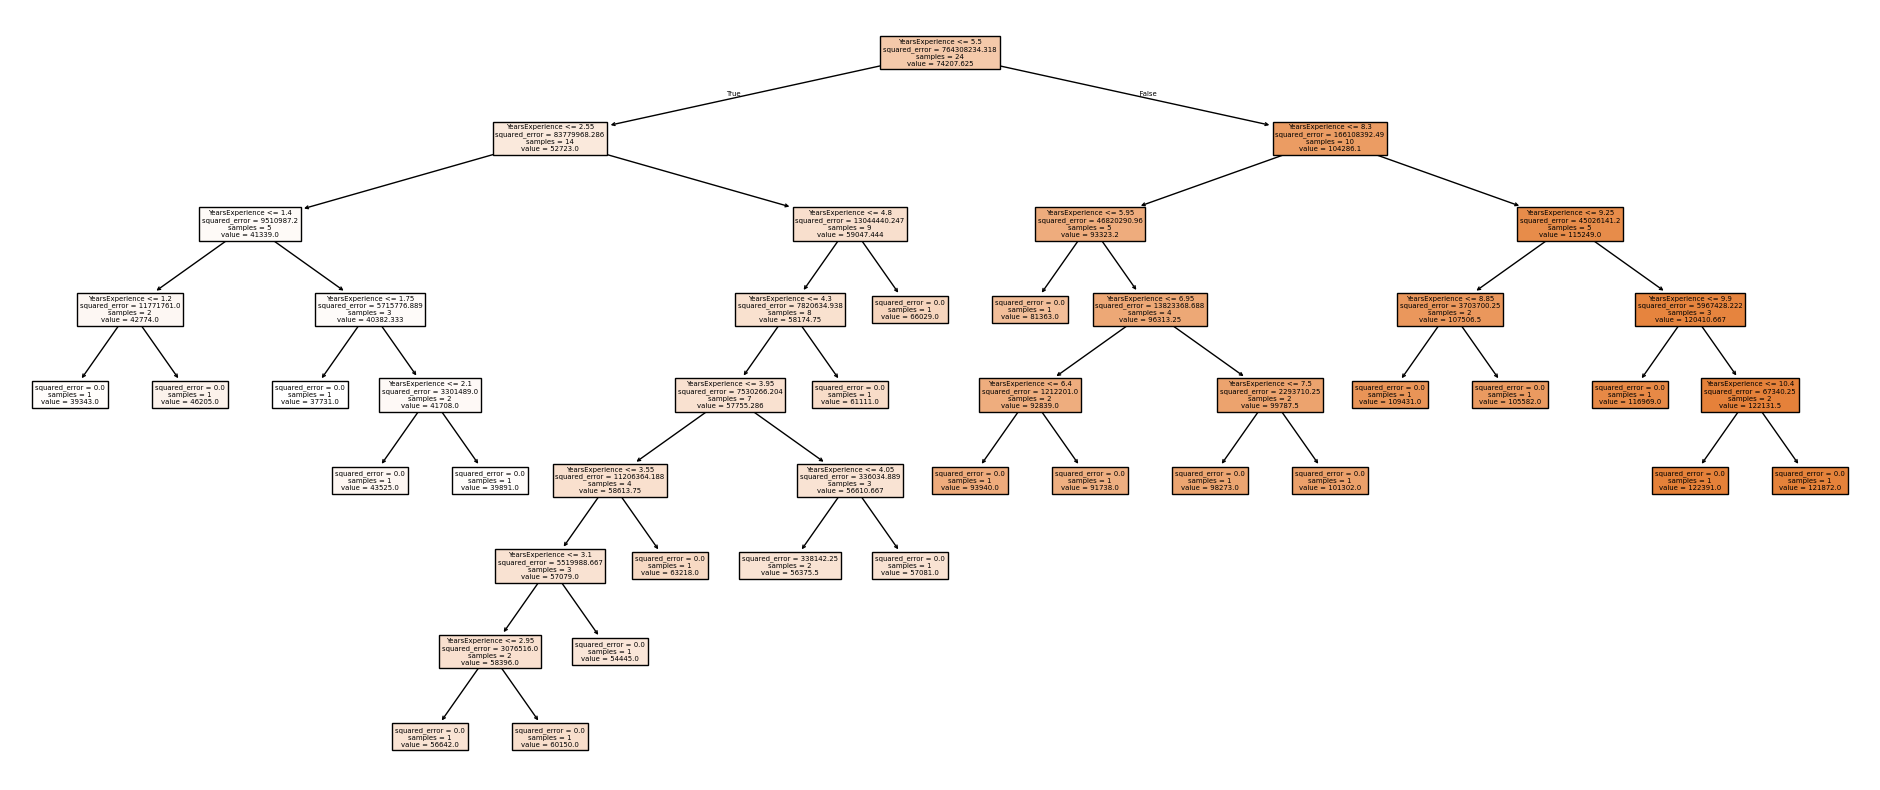

In [60]:
plt.figure(figsize=(24,10))
tree.plot_tree(dt, filled = True , feature_names = x.columns)
plt.show()

In [ ]:
# ab ye GridSearch tab krenge jab , testing and training score me bhot jyada different aayega 

In [89]:
from sklearn.tree import DecisionTreeRegressor  
from sklearn.model_selection import GridSearchCV # we are using gridsearch tuning

In [90]:
param = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 3, 5, 10],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': [None, 'sqrt', 'log2']
}

In [79]:
grid_search = GridSearchCV(
    estimator = DecisionTreeRegressor(random_state = 42) ,
    param_grid = param,
    cv= 5,
    scoring = 'r2',
    n_jobs = -1
)

In [80]:
grid_search.fit(x_train,y_train)

,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [2, 3, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [91]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'criterion': 'squared_error', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 5}


In [92]:
# y_pred = best_dt_random.predict(X_test)
y_pred = grid_search.best_estimator_.predict(x_test)

In [93]:
print("\nBest CV Score:")  #CV- cross validation
print(grid_search.best_score_)


Best CV Score:
0.927202843743722


In [1]:
# y_pred = best_dt_random.predict(x_test)
y_pred = grid_search.best_estimator_.predict(x_test)

NameError: name 'grid_search' is not defined

In [ ]:
plt.figure(figsize=(25,10))

tree.plot_tree(
    best_dt_random,
    filled=True,
    feature_names=X_train.columns
)

plt.show()